In [1]:
import random
import numpy as np
import torch

def set_seed(seed_value):
    """Sets the seed for reproducibility."""
    random.seed(seed_value)
    np.random.seed(seed_value)
    torch.manual_seed(seed_value)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed_value)
        # The two lines below are for ensuring deterministic behavior on GPU
        # but can sometimes have a performance cost.
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

# Set the seed for your experiment
set_seed(42)

In [2]:
from pathlib import Path
import pickle
import sys
import os
sys.path.append('../')

DATA_DIR = Path('../data/100000_data_points')
DATA_PATH = DATA_DIR / "synthetic_rl_datasets.pkl"
try:
    with open(DATA_PATH, 'rb') as f:
        all_data = pickle.load(f)
except FileNotFoundError:
    print(f"File not found: {DATA_PATH}")
except Exception as e:
    print(f"Error loading dataset: {e}")


In [3]:
# data class for neg1, 0, positive, all
from dataclasses import field
from dataclasses import dataclass


@dataclass
class ErrorData:
    zero: list[float] = field(default_factory=list)
    one: list[float] = field(default_factory=list)
    all: list[float] = field(default_factory=list)

In [4]:
import sys

from matplotlib.ticker import NullLocator, ScalarFormatter
sys.path.append('../')
# Add the root directory to the Python path to find your modules

from models.reward_cnn import RewardCNNCentralized
from config import MODEL_DIR, GRAPHS_DIR
import torch
from tqdm import tqdm
import os
import matplotlib.pyplot as plt
from train_scripts.train_centralized_cnn import MODEL_SAVE_PATH
import matplotlib.pyplot as plt
from config import GRAPHS_DIR
from tqdm import tqdm

key = '6x6_2_agents'
data = all_data[key]

NUM_DATA_POINTS = 100000

probabilities = [0.1, 0.3, 0.5, 0.7, 0.9]
accuracies_when_reward_1 = []
accuracies_when_reward_0 = []
accuracies = []

all_errors = {"0.1": ErrorData(), "0.3": ErrorData(), "0.5": ErrorData(), "0.7": ErrorData(), "0.9": ErrorData()}

--- PyTorch is configured to use: cuda ---


In [5]:
for p_pick_apple in probabilities:
    print(f"Training and evaluating for p_pick_apple = {p_pick_apple}")
    num_picks_apple = int(NUM_DATA_POINTS * p_pick_apple)
    num_no_picks_apple = NUM_DATA_POINTS - num_picks_apple

    data_with_apple = data['picks_apple'][:num_picks_apple]
    data_without_apple = data['doesnt_pick_apple'][:num_no_picks_apple]

    state_agentpos_reward = data_with_apple + data_without_apple
    random.shuffle(state_agentpos_reward)
    # print(len(state_agentpos_reward))
    # print(state_agentpos_reward[0])

    percent_train = 0.8
    total_train = int(0.8 * NUM_DATA_POINTS)
    state_agentpos_reward_TRAIN = state_agentpos_reward[:total_train]
    state_agentpos_reward_TEST = state_agentpos_reward[total_train:]

    WIDTH = 6
    HEIGHT = 6
    NUM_AGENTS = 2
    NUM_TRAIN_EPISODES = 1000
    BATCH_SIZE = 32
    lr = 0.01

    model = RewardCNNCentralized(WIDTH, HEIGHT, lr)
    # --- Training Loop ---
    for i in tqdm(range(NUM_TRAIN_EPISODES), desc="Training"):
        for b in range(BATCH_SIZE):
            row_index = i * BATCH_SIZE + b
            state = state_agentpos_reward_TRAIN[row_index]["state"]
            label = state_agentpos_reward_TRAIN[row_index]["reward"]
            model.add_experience_from_raw(state, label)
        model.train_batch()


    # --- Configuration (should match the trained model) ---
    num_test_episodes = len(state_agentpos_reward_TEST)
    num_agents = 2
    tol = 10e-2


    # --- Test Loop (no training here!) ---
    num_correct = 0
    num_correct_when_reward_1 = 0
    num_correct_when_reward_0 = 0
    num_reward_1 = 0
    num_reward_0 = 0
    for i in tqdm(range(num_test_episodes), leave=False):
        state = state_agentpos_reward_TEST[i]["state"]
        label = state_agentpos_reward_TEST[i]["reward"]
        # Get the raw float prediction
        prediction = model.get_model_reward_prediction_from_raw(state).item()
        error = abs(prediction - label)
        all_errors[str(p_pick_apple)].all.append(error)
        if error < tol:
            num_correct += 1
        if label == 1:
            all_errors[str(p_pick_apple)].one.append(error)
            num_reward_1 += 1
            if error < tol:
                num_correct_when_reward_1 += 1
        else:
            all_errors[str(p_pick_apple)].zero.append(error)
            num_reward_0 += 1
            if error < tol:
                num_correct_when_reward_0 += 1
    accuracy = num_correct / num_test_episodes
    accuracies.append(accuracy)
    if num_reward_1 > 0:
        accuracy_when_reward_1 = num_correct_when_reward_1 / num_reward_1
    else:
        accuracy_when_reward_1 = 0
    accuracies_when_reward_1.append(accuracy_when_reward_1)
    if num_reward_0 > 0:
        accuracy_when_reward_0 = num_correct_when_reward_0 / num_reward_0
    else:
        accuracy_when_reward_0 = 0
    accuracies_when_reward_0.append(accuracy_when_reward_0)
        


Training and evaluating for p_pick_apple = 0.1


Training: 100%|██████████| 1000/1000 [00:03<00:00, 292.71it/s]


Training and evaluating for p_pick_apple = 0.3


Training: 100%|██████████| 1000/1000 [00:02<00:00, 439.02it/s]


Training and evaluating for p_pick_apple = 0.5


Training: 100%|██████████| 1000/1000 [00:02<00:00, 473.40it/s]


Training and evaluating for p_pick_apple = 0.7


Training: 100%|██████████| 1000/1000 [00:03<00:00, 323.00it/s]


Training and evaluating for p_pick_apple = 0.9


Training: 100%|██████████| 1000/1000 [00:03<00:00, 327.74it/s]


In [6]:
print(len(all_errors["0.1"].zero))
print(len(all_errors["0.1"].one))
print(len(all_errors["0.1"].all))

18101
1899
20000


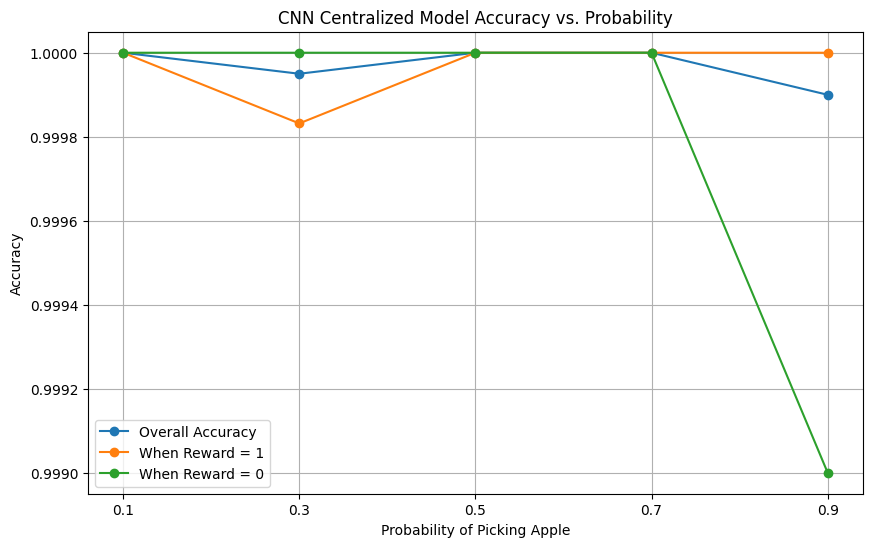

In [7]:
plt.figure(figsize=(10, 6))
plt.plot(probabilities, accuracies, marker="o", label="Overall Accuracy")
plt.plot(probabilities, accuracies_when_reward_1, marker="o", label="When Reward = 1")
plt.plot(probabilities, accuracies_when_reward_0, marker="o", label="When Reward = 0")
plt.xticks(probabilities)
plt.legend()
plt.xlabel("Probability of Picking Apple")
plt.ylabel("Accuracy")
plt.title("CNN Centralized Model Accuracy vs. Probability")
plt.grid(True)
ax = plt.gca()
ax.set_xticks(probabilities)
ax.xaxis.set_major_formatter(ScalarFormatter())

ax.xaxis.set_minor_locator(NullLocator())
plt.savefig(f"{GRAPHS_DIR}/cnn_centralized_accuracy_vs_probability.png")


[np.float64(0.0009926497805863618), np.float64(0.003421902659535408), np.float64(0.0005851188682019711), np.float64(0.0013924419649876654), np.float64(0.00375691806813702)]


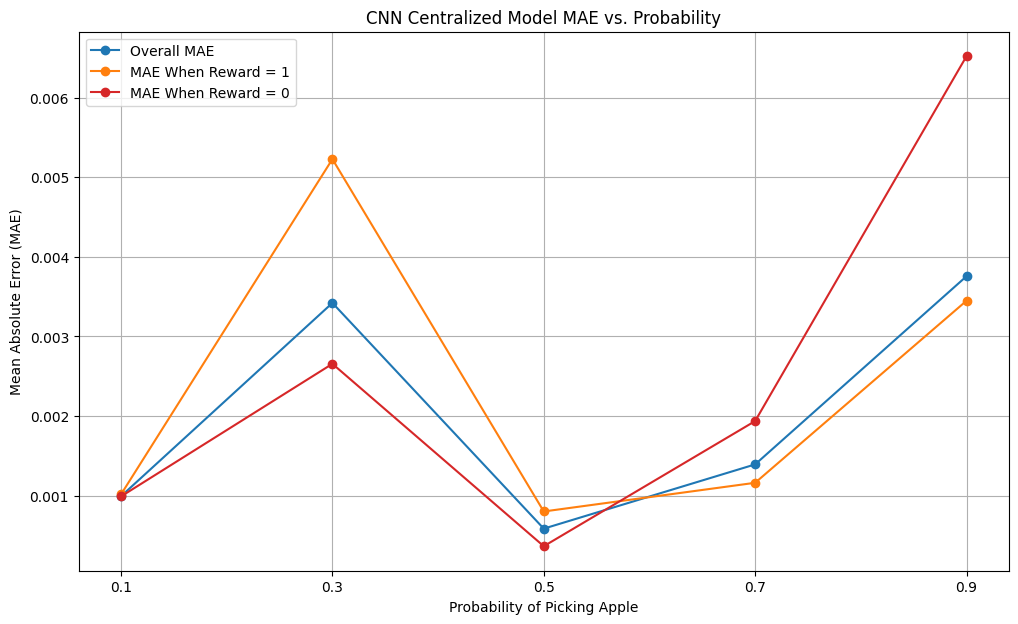

In [8]:
# plot mae of reward 1, reward 0, all
from typing import Any


from matplotlib.figure import Figure


plt.figure(figsize=(12,7))
mae_overall_list = []
mae_reward_1_list = []
mae_reward_0_list = []
for p in probabilities:
    errors: Any = all_errors[str(p)]
    mae_overall = np.mean(errors.all) if len(errors.all) > 0 else float('nan')
    mae_reward_1 = np.mean(errors.one) if len(errors.one) > 0 else float('nan')
    mae_reward_0 = np.mean(errors.zero) if len(errors.zero) > 0 else float('nan')
    mae_overall_list.append(mae_overall)
    mae_reward_1_list.append(mae_reward_1)
    mae_reward_0_list.append(mae_reward_0)
print(mae_overall_list)
plt.plot(probabilities, mae_overall_list, marker="o", label="Overall MAE", color='tab:blue')
plt.plot(probabilities, mae_reward_1_list, marker="o", label="MAE When Reward = 1", color='tab:orange')
plt.plot(probabilities, mae_reward_0_list, marker="o", label="MAE When Reward = 0", color='tab:red')
plt.xticks(probabilities)
plt.legend()
plt.xlabel("Probability of Picking Apple")
plt.ylabel("Mean Absolute Error (MAE)")
plt.title("CNN Centralized Model MAE vs. Probability")
plt.grid(True)
